# Visualization and Data Inspection – Inverse Problem for JPA Scattering Matrix

This notebook loads experimental scattering matrix data acquired from a Josephson Parametric Amplifier (JPA)
and provides interactive tools to visualize and inspect the results of the inverse-problem reconstruction.

**Workflow overview:**
1. Load the raw experimental USB (Upper Sideband) scattering matrix data from an HDF5 file.
2. Load the reconstructed pumping scheme (frequency-conversion and squeezing pumps) obtained via the inverse-problem optimization.
3. Compute and display the theoretical scattering matrix from the recovered pump parameters.
4. Compare the experimental and theoretical scattering matrices side by side using interactive sliders.
5. (Optional) Save selected data arrays to disk for further analysis.

**Requirements:**
- `numpy`, `scipy`, `matplotlib`, `h5py`, `ipywidgets`, `statsmodels`
- Custom modules: `myPy_functions` (`my`) and `PyPump` (`pp`) — included in this repository.

In [1]:
# =============================================================================
# Section 1 – Imports and global parameters
# =============================================================================

import numpy as np
import scipy as sci
import matplotlib.pyplot as plt
from matplotlib import colors
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output  # clear_output(wait=True)
import time
import os
import sys
import h5py
from scipy.optimize import curve_fit

# --- Custom modules (must be in the Python path) ---
# myPy_functions: collection of utility functions for signal processing and matrix operations
# PyPump:         module for constructing JPA pump coupling matrices
import myPy_functions as my
import PyPump as pp

# --- JPA and frequency comb parameters ---
f0 = 4.2           # [GHz]  Resonance frequency of the JPA
omega0 = 2 * np.pi * f0
Delta_f = 0.1e-3   # [GHz]  Mode spacing (typically 100 kHz)
Delta = 2 * np.pi * Delta_f
c = 299_792_458    # [m/s]  Speed of light (kept for reference)

# --- Matplotlib style settings ---
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['font.size'] = 20
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['legend.frameon'] = False
plt.rcParams["font.weight"] = "normal"
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

In [2]:
# =============================================================================
# Section 2 – Helper function definitions
# =============================================================================
# This cell defines all utility functions used throughout the notebook:
#   - load_ExpData:           reads a named dataset from an HDF5 file
#   - load_pumping_scheme:    loads a saved pump parameter set from disk
#   - assemble_M:             builds the total interaction matrix from pump coefficients
#   - build_coeff_vectors:    converts a pump list into complex coefficient arrays
#   - build_D_from_allmodes:  builds the diagonal drift matrix D
#   - to_xp / to_aa:          basis-change helpers between (a, a*) and (x, p)

pumping_scheme = "Scattering"   # for dataset to create Fig.3
dataset = '2025-11-14_10_23_31' # for dataset to create Fig.3
g_fc = 17
value_figure = -60

# pumping_scheme = "Pumping Scheme NonRec" # for dataset to create Fig.4
# dataset = '2025-11-21_16_40_49'          # for dataset to create Fig.4
# g_fc = 45
# value_figure = -40


def load_ExpData(file_, idx_str_):
    """
    Load experimental scattering data from an HDF5 file.

    Parameters
    ----------
    file_ : str
        Path to the HDF5 file containing the experimental data.
    idx_str_ : str
        Key string identifying the dataset group within the HDF5 file
        (e.g. 'Scattering/2025-10-24_15_44_45').

    Returns
    -------
    dict
        Dictionary containing:
        df, USB, USB_std, freq_sig,
        freq_param_pumps, amp_param_pumps, phase_param_pumps,
        freq_fc_pumps, amp_fc_pumps, phase_fc_pumps.
    """
    with h5py.File(file_, "r") as dataset:
        return dict(
            df=np.asarray(dataset[idx_str_]["df"]),
            USB=np.asarray(dataset[idx_str_]["USB"]),
            USB_std=np.asarray(dataset[idx_str_]["USB std"]),
            freq_sig=np.asarray(dataset[idx_str_]["freq sig"]),
            freq_param_pumps=np.asarray(dataset[idx_str_]["freq param pumps"]),
            amp_param_pumps=np.asarray(dataset[idx_str_]["amp param pumps"]),
            phase_param_pumps=np.asarray(dataset[idx_str_]["phase param pumps"]),
            freq_fc_pumps=np.asarray(dataset[idx_str_]["freq fc pumps"]),
            amp_fc_pumps=np.asarray(dataset[idx_str_]["amp fc pumps"]),
            phase_fc_pumps=np.asarray(dataset[idx_str_]["phase fc pumps"]),
            pump_scheme=np.asarray(dataset[idx_str_]["pumping scheme"]),
        )


def load_pumping_scheme(number, base_dir=None, amp_threshold=1e-8):
    """
    Load a pumping scheme (arrays + back data) saved under pump_scheme_{number}/.
    Pumps with amplitudes below amp_threshold are removed.

    Parameters
    ----------
    number : int
        Identifier number of the pumping scheme.
    base_dir : str, optional
        Base directory where the schemes are saved.
        Defaults to the repository path if None.
    amp_threshold : float, optional
        Minimum amplitude to keep a pump (default: 1e-8).

    Returns
    -------
    dict
        Dictionary with keys:
        amp_FC, phase_FC, k_FC, amp_SQ, phase_SQ, k_SQ,
        gp_back, omega_back
    """
    # Default path — update this to point to your local copy of the pumping scheme directory
    if base_dir is None:


        base_dir = pumping_scheme #"Scattering"  

    scheme_dir = os.path.join(base_dir, f"pump_scheme_{number}")
    fname_arrays = os.path.join(scheme_dir, "pump_arrays.npz")
    fname_back = os.path.join(scheme_dir, "pump_back.npz")

    # Verify that both required files exist before loading
    if not os.path.exists(fname_arrays):
        raise FileNotFoundError(f"File not found: {fname_arrays}")
    if not os.path.exists(fname_back):
        raise FileNotFoundError(f"File not found: {fname_back}")

    # Load pump arrays and background data
    data_arrays = np.load(fname_arrays, allow_pickle=True)
    data_back = np.load(fname_back, allow_pickle=True)

    amp_FC, phase_FC, k_FC = data_arrays["amp_FC"], data_arrays["phase_FC"], data_arrays["k_FC"]
    amp_SQ, phase_SQ, k_SQ = data_arrays["amp_SQ"], data_arrays["phase_SQ"], data_arrays["k_SQ"]
    gp_back, omega_back = data_back["gp_back"], data_back["omega_back"]

    # Filter out pumps whose amplitude is below the threshold (numerical noise)
    mask_FC = amp_FC >= amp_threshold
    mask_SQ = amp_SQ >= amp_threshold

    amp_FC, phase_FC, k_FC = amp_FC[mask_FC], phase_FC[mask_FC], k_FC[mask_FC]
    amp_SQ, phase_SQ, k_SQ = amp_SQ[mask_SQ], phase_SQ[mask_SQ], k_SQ[mask_SQ]

    scheme = {
        "amp_FC": amp_FC,
        "phase_FC": phase_FC,
        "k_FC": k_FC,
        "amp_SQ": amp_SQ,
        "phase_SQ": phase_SQ,
        "k_SQ": k_SQ,
        "gp_back": gp_back,
        "omega_back": omega_back,
    }

    print(f"✅ Pumping scheme loaded from: {scheme_dir}")
    print(f" ├─ FC pumps kept: {len(amp_FC)} (threshold={amp_threshold})")
    print(f" └─ SQ pumps kept: {len(amp_SQ)}")

    return scheme


def assemble_M(g, gamma,
               G_plus_set, G_minus_set,
               Gamma_plus_set, Gamma_minus_set):
    """
    Assemble the total interaction matrix M as:

        M = Σ_k [ g_k G_k^+ + g_k* G_k^- + γ_k Γ_k^+ + γ_k* Γ_k^- ]

    where:
      - g_k   are frequency-conversion pump amplitudes (complex),
      - γ_k   are squeezing pump amplitudes (complex),
      - G_k^± and Γ_k^± are predefined coupling matrices for each pump mode k.

    Parameters
    ----------
    g : array-like, length N_m - 1
        Complex conversion pump coefficients.
    gamma : array-like, length 2*N_m - 1
        Complex squeezing pump coefficients (centered at k=0).
    G_plus_set, G_minus_set : list of 2D arrays
        Coupling matrices for conversion pumps.
    Gamma_plus_set, Gamma_minus_set : list of 2D arrays
        Coupling matrices for squeezing pumps.

    Returns
    -------
    M : ndarray, shape (2*N_m, 2*N_m)
        Total interaction matrix.
    """
    # Initialize M as zero matrix (same shape and dtype as the G matrices)
    M = np.zeros_like(G_plus_set[0], dtype=complex)

    # Add contributions from frequency-conversion pumps (k = 1 … N_m-1)
    for idx, gk in enumerate(g, start=1):
        M += gk * G_plus_set[idx - 1]
        M += np.conjugate(gk) * G_minus_set[idx - 1]

    # Add contributions from squeezing pumps (k = -(N_m-1) … N_m-1)
    N_m = len(gamma) // 2 + 1
    for offset, γk in enumerate(gamma):
        k = offset - (N_m - 1)  # Convert linear offset to signed mode index k
        M += γk * Gamma_plus_set[offset]
        M += np.conjugate(γk) * Gamma_minus_set[offset]

    return M


def build_coeff_vectors(pumps, N_m, g1_value):
    """
    Convert a list of pump definitions into complex coefficient vectors.

    Each pump is described by a tuple:
        (k, amp_rel, phase, is_squeezing)
    where:
      - k          : mode index (positive for conversion, signed for squeezing)
      - amp_rel    : amplitude relative to the base coupling g1_value
      - phase      : pump phase in radians
      - is_squeezing : True for squeezing pump, False for frequency-conversion pump

    Parameters
    ----------
    pumps : list of tuples
        Each tuple: (k, amp_rel, phase, is_squeezing)
    N_m : int
        Number of modes.
    g1_value : float
        Reference coupling strength used to scale pump amplitudes.

    Returns
    -------
    g : ndarray, shape (N_m - 1,)
        Complex conversion pump coefficients.
    gamma : ndarray, shape (2*N_m - 1,)
        Complex squeezing pump coefficients.
    """
    g = np.zeros(N_m - 1, dtype=complex)
    gamma = np.zeros(2 * N_m - 1, dtype=complex)

    for k, amp_rel, phase, is_sq in pumps:
        coeff = amp_rel * g1_value * np.exp(1j * phase) / 2
        if not is_sq:
            # Frequency-conversion pump: valid index range [1, N_m-1]
            if 1 <= k <= N_m - 1:
                g[k - 1] = coeff
            else:
                raise ValueError(f"Conversion pump index k={k} out of range [1..{N_m - 1}]")
        else:
            # Squeezing pump: valid index range [-(N_m-1), N_m-1]
            idx = k + (N_m - 1)
            if 0 <= idx < 2 * N_m - 1:
                gamma[idx] = coeff
            else:
                raise ValueError(f"Squeezing pump index k={k} out of range [-{N_m - 1}..{N_m - 1}]")

    return g, gamma


def build_D_from_allmodes(allmodes_freq, omega0, gamma):
    """
    Construct the diagonal drift matrix D of shape (2*nmodes, 2*nmodes).

    For each pair of (negative, positive) frequency components at index i:
      - D[i,   i]   = -ω_{-k} - omega0 + i*γ/2
      - D[i+1, i+1] = -ω_{+k} + omega0 + i*γ/2

    The array ``allmodes_freq`` is ordered as:
      [ω_{-n}, -ω_{-n}, ω_{-(n-1)}, -ω_{-(n-1)}, ..., ω_{-1}, -ω_{-1}]

    Parameters
    ----------
    allmodes_freq : ndarray, length 2*nmodes
        Interleaved negative and positive frequency components.
    omega0 : float
        JPA resonance frequency [rad/GHz].
    gamma : float
        Total decay rate [GHz].

    Returns
    -------
    D : ndarray, shape (2*nmodes, 2*nmodes), dtype=complex
    """
    nm2 = allmodes_freq.size  # = 2 * nmodes
    D = np.zeros((nm2, nm2), dtype=complex)
    for i in range(0, nm2, 2):
        ω_minus_k = allmodes_freq[i]
        ω_plus_k  = allmodes_freq[i + 1]
        D[i,   i]   = -ω_minus_k - omega0 + 1j * gamma / 2
        D[i+1, i+1] = -ω_plus_k  + omega0 + 1j * gamma / 2
    return D


def to_xp(S_a, U):
    """Change basis from (a, a*) to (x, p): S_xp = U† S_a U."""
    return U.conj().T @ S_a @ U


def to_aa(S_xp, U):
    """Change basis from (x, p) to (a, a*): S_a = U S_xp U†."""
    return U @ S_xp @ U.conj().T

In [3]:
# =============================================================================
# Section 3 – Data file selection
# =============================================================================
# Specify the HDF5 file path and the dataset key to load.
# The dataset key is formed as "cooldown/run_timestamp".
#
# NOTE: update `file` to point to your local copy of the HDF5 data file.

file = r'2025-11.hdf5'
cooldown = r'Scattering'
run = dataset

# Build the HDF5 group key from cooldown label and run timestamp
idx_str = "{}/{}".format(cooldown, run)
print(idx_str)

Scattering/2025-11-14_10_23_31


In [4]:
# Load the experimental data from the given file and index string
data = load_ExpData(file, idx_str)

# Extract the USB (Upper SideBand) data array
# Shape: (Ndf, Nfc, Nfc_phases, Nparam, Nparam_phases, Nmodes, Nmodes)
USB = data["USB"]

# Extract the standard deviation of the USB data (same shape as USB)
USB_std = data["USB_std"]

# Extract the pump amplitudes for the parametric pumps (1D vector)
amp_param = data["amp_param_pumps"]

# Extract the pump amplitudes for the frequency comb pumps (1D vector)
amp_fc = data["amp_fc_pumps"]

# Extract the frequency detuning values (vector)
df = data["df"]

# Extract used pumping scheme
number = int(data["pump_scheme"])

# Extract the frequency values of the pumps
freq_param_pumps = data["freq_param_pumps"]
freq_fc_pumps = data["freq_fc_pumps"]

delta_kHZ = Delta_f * 1e9
k_SQ_used = (freq_param_pumps - 2e9 * f0) / delta_kHZ
k_FC_used = freq_fc_pumps / delta_kHZ

print("\n=== Loaded Pumping Scheme ===")
print(f" ")
print("\nSQUEEZING PUMPS:")
for i in range(len(k_SQ_used)):
    print(f"  k={k_SQ_used[i]}")

print("\nFREQUENCY CONVERSION PUMPS:")
for i in range(len(k_FC_used)):
    print(f"  k={k_FC_used[i]}")

# --- Parsing the new shape of the USB array ---
# Unpack the dimensions of the USB array
# Ndf: number of detuning values
# Nfc: number of frequency comb amplitudes
# Nfc_phases: number of phases for each comb pump
# Nparam: number of parametric pump amplitudes
# Nparam_phases: number of phases for each parametric pump
# Nmodes: number of modes in the system
# _: duplicated Nmodes dimension for matrix structure (USB is a 2D matrix per configuration)
Ndf, Nfc, Nfc_phases, Nparam, Nparam_phases, Nmodes, _ = USB.shape



=== Loaded Pumping Scheme ===
 

SQUEEZING PUMPS:
  k=[-14.  -7.  10.]

FREQUENCY CONVERSION PUMPS:
  k=[ 2.  3. 13.]


In [5]:
# Print the dataset dimensions for a quick sanity check
print("Ndf (detuning points):        ", Ndf)
print("Nfc (comb amplitudes):        ", Nfc)
print("Nfc_phases (comb phases):     ", Nfc_phases)
print("Nparam (param amplitudes):    ", Nparam)
print("Nparam_phases (param phases): ", Nparam_phases)
print("Nmodes (signal modes):        ", Nmodes)

Ndf (detuning points):         1
Nfc (comb amplitudes):         20
Nfc_phases (comb phases):      1
Nparam (param amplitudes):     1
Nparam_phases (param phases):  1
Nmodes (signal modes):         31


### Explanation of the shape of `usb_arr`

The variable `usb_arr` is a complex-valued NumPy array with the following shape:

```python
usb_arr = np.zeros((len(_df_arr), nr_fc_amps, nr_fc_phases, nr_pump_amps, nr_pump_phases,
                        nr_sig_freqs, nr_sig_freqs), dtype=complex)



Where:

- `len(_df_arr)`: number of frequency detuning (\(\Delta f\)) points considered in the analysis.
- `nr_fc_amps`: number of frequency comb amplitude values used.
- `nr_fc_phases`: number of frequency comb phase values considered.
- `nr_pump_amps`: number of parametric pump amplitude values varied.
- `nr_pump_phases`: number of parametric pump phase values varied.
- `nr_sig_freqs`: number of signal frequencies considered in the system.

The last two indices correspond to the dimensions of the scattering matrix $S$ at two modes, representing the input and output signal frequencies.

In other words, for each combination of:

- detuning,
- frequency comb amplitude and phase,
- pump amplitude and phase,

`usb_arr` stores a complex square matrix of size $nr\_sig\_freqs \times nr\_sig\_freqs$ representing the experimental or simulated scattering matrix of the system.

---

This data structure allows analyzing how the scattering matrix $S$ changes with respect to experimental and phase parameters, facilitating the extraction and visualization of specific slices for chosen parameter values.


In [6]:
# Define the full experimental scattering matrix Sexp_tot from USB,
# selecting only the case with fc_phase = 0 (i.e., third index = 0)
Sexp_tot = USB[0, :, 0, :, 0, :, :]  

# The original USB array has shape:
# USB[ df, fc_val, fc_phases, param_val, param_phases, nmodes, nmodes ]
# After slicing, Sexp_tot has shape:
# Sexp_tot[ fc_val, param_val, nmodes, nmodes ]

# --- Compute reference matrix and background level ---
S0exp_ref = np.zeros(Ndf)       # Initialize reference value array
backgnd_dB = np.zeros(Ndf)      # Initialize background level array in dB

# Select the reference matrix: case with zero comb pump amplitude and zero parametric pump amplitude
# Squeeze removes dimensions of size 1 (in this case, fc_val=0 and param_val=0)
Sref_T = np.squeeze(Sexp_tot[0, 0, :, :])

# Transpose the reference matrix to get Sref with correct orientation
Sref = np.transpose(Sref_T)

# Compute the mean of the diagonal elements of the reference matrix (i.e., average of mode powers)
S0exp_ref = np.mean(np.abs(np.diag(Sref)))

# Estimate the background level from a region assumed to be "off-diagonal"
mask_diag = ~np.eye(Sref.shape[0], dtype=bool)
background = Sref[mask_diag].mean()

# Convert background-to-signal ratio to dB
backgnd_dB = my.dB(background / S0exp_ref)

# --- Generate mode frequency vectors ---
# Create vectors with the mode frequencies, their labels, and the full frequency list
modes_freq, modes_labels, allmodes_freq = my.generate_freq_vectors(Nmodes, omega0, Delta)

# Convert mode frequencies from angular frequency (rad/s) to GHz
modes_freq_GHz = modes_freq / (2 * np.pi)


In [7]:
# =============================================================================
# Section 4 – Interactive visualization of the experimental scattering matrix
# =============================================================================
# This cell provides an interactive widget to explore the magnitude and phase
# of the experimental scattering matrix Sexp as a function of:
#   - the parametric (squeezing) pump amplitude index (g_p slider)
#   - the frequency comb amplitude index (g_fc slider)
#   - a phase-noise threshold (φ_n slider): matrix elements whose amplitude
#     in dB is below this threshold are set to real-positive (phase zeroed),
#     suppressing numerical phase noise at low-signal entries.
#
# The two panels show:
#   Left:  |S_exp| in dB, normalized to the reference (no-pump) diagonal
#   Right: ∠S_exp in units of π

def stuff_to_run_and_display(param_value, fc_value, phNoise_value):
    """Callback for the interactive widget (first version – amplitude and phase panels)."""
    # Map slider values to array indices and noise threshold
    param_idx = param_value
    fc_idx = fc_value
    phNoise_dB = phNoise_value

    # Bring global arrays into scope
    global Sexp_tot, S0exp_ref, backgnd_dB
    global Ndf, Nparam, Nfc, Nparam_phases, Nfc_phases, Nmodes, df

    # Extract the scattering matrix for the selected fc and param amplitudes;
    # squeeze removes the singleton phase dimensions
    Sexp = np.squeeze(Sexp_tot[fc_idx, param_idx, :, :])

    # Compute element-wise magnitude
    Sexp_abs = np.abs(Sexp)

    # Convert to dB, normalized by the reference (no-pump) diagonal mean
    Sexp_abs_dB = my.dB(Sexp_abs / S0exp_ref)

    # Apply phase-noise mask: entries below the threshold are set to |Sexp|
    # (real positive), effectively zeroing their phase contribution
    mask = Sexp_abs_dB < phNoise_dB
    Sexp_new = Sexp.copy()
    Sexp_new[mask] = Sexp_abs[mask]

    # Recompute magnitude and phase after masking
    Sexp_abs = np.abs(Sexp_new)
    Sexp_ang = np.angle(Sexp_new)

    # Report the detuning value(s) used in the dataset
    for df_val in df:
        print('df =', df_val / 1e3, 'kHz')

    # --- Plot ---
    fig, ax = plt.subplots(1, 2, figsize=(15, 7), layout="constrained")
    top = modes_labels[Nmodes - 1]  # Axis extent in mode-frequency units

    # Left panel: amplitude in dB
    pl0 = ax[0].imshow(my.dB(Sexp_abs / S0exp_ref), cmap='GnBu_r',
                       extent=[-top, top, top, -top], vmin=-70, vmax=10)
    plt.colorbar(pl0, ax=ax[0], label='Amplitude [dB]')
    ax[0].set_title(r'$|S_{\mathrm{exp}}|$')

    # Right panel: phase in units of π
    pl1 = ax[1].imshow(Sexp_ang / np.pi, cmap='GnBu_r',
                       extent=[-top, top, top, -top], vmin=-1, vmax=1)
    plt.colorbar(pl1, ax=ax[1], label=r'Phase [$\pi$]')
    ax[1].set_title(r'$\angle S_{\mathrm{exp}}$')


# --- Interactive sliders ---
param_slider   = widgets.IntSlider(min=0, max=Nparam - 1, step=1, value=0, description=r'$g_p$')
fc_slider      = widgets.IntSlider(min=0, max=Nfc - 1, step=1, value=0, description=r'$g_{fc}$')
phNoise_slider = widgets.FloatSlider(min=-60.0, max=10.0, step=0.1, value=-35, description=r'$\phi_n$ [dB]')

widgets.interact(stuff_to_run_and_display,
                 param_value=param_slider,
                 fc_value=fc_slider,
                 phNoise_value=phNoise_slider)

plt.show()

interactive(children=(IntSlider(value=0, description='$g_p$', max=0), IntSlider(value=0, description='$g_{fc}$…

In [8]:
# =============================================================================
# Section 5 – Load the recovered pumping scheme and build the theoretical S-matrix
# =============================================================================
# This cell:
#   1. Loads the pump parameters (amplitudes, phases, mode indices) recovered
#      by the inverse-problem optimization (pump_scheme_1).
#   2. Sets up the JPA system parameters (loss rates, number of modes, basis matrices).
#   3. Builds the theoretical scattering matrix S from the recovered pump vector g_p.

# --- Load the recovered pumping scheme ---
scheme = load_pumping_scheme(number)

amp_SQ     = scheme["amp_SQ"]      # Squeezing pump amplitudes
phase_SQ   = scheme["phase_SQ"]    # Squeezing pump phases [rad]
k_SQ       = scheme["k_SQ"]        # Squeezing pump mode indices

amp_FC     = scheme["amp_FC"]      # Frequency-conversion pump amplitudes
phase_FC   = scheme["phase_FC"]    # Frequency-conversion pump phases [rad]
k_FC       = scheme["k_FC"]        # Frequency-conversion pump mode indices

gp_back    = scheme["gp_back"]     # Full recovered pump vector g_p (complex, all modes)
omega_back = scheme["omega_back"]  # Resonance frequencies used in the optimization

print("=== Loaded Pumping Scheme ===")
print("SQUEEZING PUMPS:")
for i in range(len(amp_SQ)):
    print(f"  k={k_SQ[i]:>3d}, amp={amp_SQ[i]:.3e}, phase={phase_SQ[i]:.3f} rad")

print("\nFREQUENCY CONVERSION PUMPS:")
for i in range(len(amp_FC)):
    print(f"  k={k_FC[i]:>3d}, amp={amp_FC[i]:.3e}, phase={phase_FC[i]:.3f} rad")

# --- System parameters ---
gamma_int  = 0.0                              # Internal loss rate [GHz]
gamma_ext  = 2 * np.pi * 100e6 / 1e9         # External (coupling) decay rate [GHz]
g1_value   = 24                               # Reference pump coupling strength
gamma_over_g = 10.0                           # Dissipation-to-coupling ratio γ/g

# Compute composite decay rates
gamma_r    = g1_value * gamma_over_g          # Reference decay rate (in units of g1)
gamma0_ext = gamma_ext * gamma_r              # Scaled external decay rate
gamma      = gamma_int + gamma0_ext           # Total decay rate γ = γ_int + γ_ext

# Number of modes equals the number of signal frequencies in the dataset
nmodes = Nmodes

# Coupling-to-environment matrix K (square root of external decay rate × identity)
K = np.identity(2 * nmodes) * np.sqrt(gamma0_ext)
# Identity matrix (used for S-matrix formula: S = iK M^{-1} K - I)
Id = np.eye(2 * nmodes, dtype=complex)

# --- Basis-change matrices: (a, a*) ←→ (x, p) ---
# U maps quadrature basis to mode operator basis: a⃗ = U x⃗
U_2by2 = (1 / np.sqrt(2)) * np.array([[1,  1j],
                                       [1, -1j]])
Udag_2by2 = (1 / np.sqrt(2)) * np.array([[ 1,  1 ],
                                          [-1j, 1j]])
# Extend to the full nmodes-mode system via Kronecker product
U    = np.kron(np.eye(nmodes, dtype=complex), U_2by2)
Udag = np.linalg.inv(U)

eps = 1e-12  # Small regularization constant (prevents log(0) in dB conversion)

# --- Generate mode frequency vectors ---
nn = 2 * Nmodes  # Total number of mode components (positive + negative frequencies)
modes_freq, modes_labels, allmodes_freq = my.generate_freq_vectors(Nmodes, omega0, Delta)

# --- Define the pumping configuration for the theoretical S-matrix ---
# Lists are intentionally empty here; the theoretical S-matrix is computed
# directly from the recovered g_p vector (gp_back) rather than from an
# explicit pump list.
squeezing_pumps  = []
conversion_pumps = []
pumps = squeezing_pumps + conversion_pumps

# Build complex coefficient vectors for conversion (g) and squeezing (gam) pumps
g, gam = build_coeff_vectors(pumps, Nmodes, g1_value)

# Generate the full sets of coupling matrices G^± and Γ^± for all mode pairs
G_plus_set,     G_minus_set     = pp.generate_G_set(Nmodes)
Gamma_plus_set, Gamma_minus_set = pp.generate_Gamma_set(Nmodes)

# Assemble the total interaction matrix M = M_pumps + D (diagonal drift part)
M = assemble_M(g, gam,
               G_plus_set,    G_minus_set,
               Gamma_plus_set, Gamma_minus_set)
D = build_D_from_allmodes(allmodes_freq, omega0, gamma)
M = M + D

# Compute the input–output scattering matrix S = iK M^{-1} K - I
M_inv   = np.linalg.inv(M)
S0      = 1j * K @ M_inv @ K - Id
S0_small = my.extract_small_S(S0)  # Extract the physical (nmodes × nmodes) subblock
S0num_ref = np.mean(np.abs(np.diag(S0_small)))  # Reference amplitude for normalization

S0_dB = my.dB(np.abs(S0_small) / S0num_ref + eps)

# --- Theoretical S-matrix from the recovered pump vector ---
# Compute the scattering matrix predicted by the inverse-problem solution (gp_back)
Saa_target, _ = my.compute_bigS_from_g(Nmodes, gp_back, omega_back, omega0, Delta)
Sxp_target    = np.real(Udag.dot(Saa_target).dot(U))  # Convert to quadrature basis

# Extract the physical subblock of the target S-matrices
Saa_target_small = my.extract_small_S(Saa_target)
Sxp_target_small = my.extract_small_S(Sxp_target)

✅ Pumping scheme loaded from: Scattering\pump_scheme_3
 ├─ FC pumps kept: 3 (threshold=1e-08)
 └─ SQ pumps kept: 3
=== Loaded Pumping Scheme ===
SQUEEZING PUMPS:
  k=-14, amp=1.591e-01, phase=0.561 rad
  k= -7, amp=1.036e+00, phase=1.205 rad
  k= 10, amp=6.936e-01, phase=2.324 rad

FREQUENCY CONVERSION PUMPS:
  k=  2, amp=7.350e-01, phase=0.939 rad
  k=  3, amp=5.687e-02, phase=-1.400 rad
  k= 13, amp=4.380e-01, phase=-0.723 rad


In [9]:
vmin = -60  # Lower bound for the dB color scale [dB]
vmax = 10   # Upper bound for the dB color scale [dB]

# Compute the amplitude of the target (theoretical) scattering matrix in dB.
# A small epsilon is added before taking the log to avoid log(0) for zero-valued entries.
target_db = my.dB(np.abs(Saa_target_small) / S0num_ref + eps)

In [10]:
# =============================================================================
# Section 6 – Interactive comparison: experiment vs. theory
# =============================================================================
# This cell provides a side-by-side comparison of:
#   Left panel:  |S_exp| in dB — experimental scattering matrix magnitude
#   Right panel: |S_target| in dB — theoretical scattering matrix from the
#                recovered pumping scheme (inverse-problem solution)
#
# Sliders allow control over:
#   g_p       — parametric (squeezing) pump amplitude index
#   g_fc      — frequency-comb pump amplitude index
#   φ_n [dB]  — phase-noise threshold (entries below this are set real-positive)
#   v_min/max — color-scale bounds in dB

def stuff_to_run_and_display(param_value, fc_value, phNoise_value, vmin_value, vmax_value):
    """Callback for the interactive widget (second version – experiment vs. theory)."""
    param_idx  = param_value
    fc_idx     = fc_value
    phNoise_dB = phNoise_value
    vmin_idx   = vmin_value
    vmax_idx   = vmax_value

    global Sexp_tot, S0exp_ref, backgnd_dB
    global Ndf, Nparam, Nfc, Nparam_phases, Nfc_phases, Nmodes, df

    # Extract the experimental scattering matrix for the selected parameter values
    Sexp = np.squeeze(Sexp_tot[fc_idx, param_idx, :, :])

    # Compute magnitude and dB-normalized amplitude
    Sexp_abs     = np.abs(Sexp)
    Sexp_abs_dB  = my.dB(Sexp_abs / S0exp_ref)

    # Suppress phase noise: entries below the threshold are set to their magnitude
    mask = Sexp_abs_dB < phNoise_dB
    Sexp_new = Sexp.copy()
    Sexp_new[mask] = Sexp_abs[mask]

    # Recompute magnitude after masking
    Sexp_abs = np.abs(Sexp_new)

    # Report detuning
    for df_val in df:
        print('df =', df_val / 1e3, 'kHz')

    # --- Plot ---
    fig, ax = plt.subplots(1, 2, figsize=(15, 7), layout="constrained")
    top = modes_labels[Nmodes - 1]  # Axis half-extent in mode-frequency units

    # Left panel: experimental |S_exp| in dB
    pl0 = ax[0].imshow(my.dB(Sexp_abs / S0exp_ref), cmap='GnBu_r',
                       extent=[-top, top, top, -top], vmin=vmin_idx, vmax=vmax_idx)
    plt.colorbar(pl0, ax=ax[0], label='Amplitude [dB]')
    ax[0].set_title(r'$|S_{\mathrm{exp}}|$')

    # Right panel: theoretical |S_target| in dB (from inverse-problem solution)
    pl1 = ax[1].imshow(target_db, cmap='GnBu_r',
                       extent=[-top, top, top, -top], vmin=vmin_idx, vmax=vmax_idx)
    plt.colorbar(pl1, ax=ax[1], label='Amplitude [dB]')
    ax[1].set_title(r'$|S_{\mathrm{target}}|$')


# --- Interactive sliders ---
param_slider   = widgets.IntSlider(min=0, max=Nparam - 1, step=1, value=0, description=r'$g_p$')
fc_slider      = widgets.IntSlider(min=0, max=Nfc - 1, step=1, value=g_fc, description=r'$g_{fc}$')
phNoise_slider = widgets.FloatSlider(min=-60.0, max=10.0, step=0.1, value=-35, description=r'$\phi_n$ [dB]')
vmin_slider    = widgets.FloatSlider(min=-70.0, max=10.0, step=0.1, value=value_figure, description=r'$v_{min}$ [dB]')
vmax_slider    = widgets.FloatSlider(min=0.0,  max=20.0, step=0.1, value=0,  description=r'$v_{max}$ [dB]')

widgets.interact(stuff_to_run_and_display,
                 param_value=param_slider,
                 fc_value=fc_slider,
                 phNoise_value=phNoise_slider,
                 vmin_value=vmin_slider,
                 vmax_value=vmax_slider)

plt.show()

interactive(children=(IntSlider(value=0, description='$g_p$', max=0), IntSlider(value=17, description='$g_{fc}…

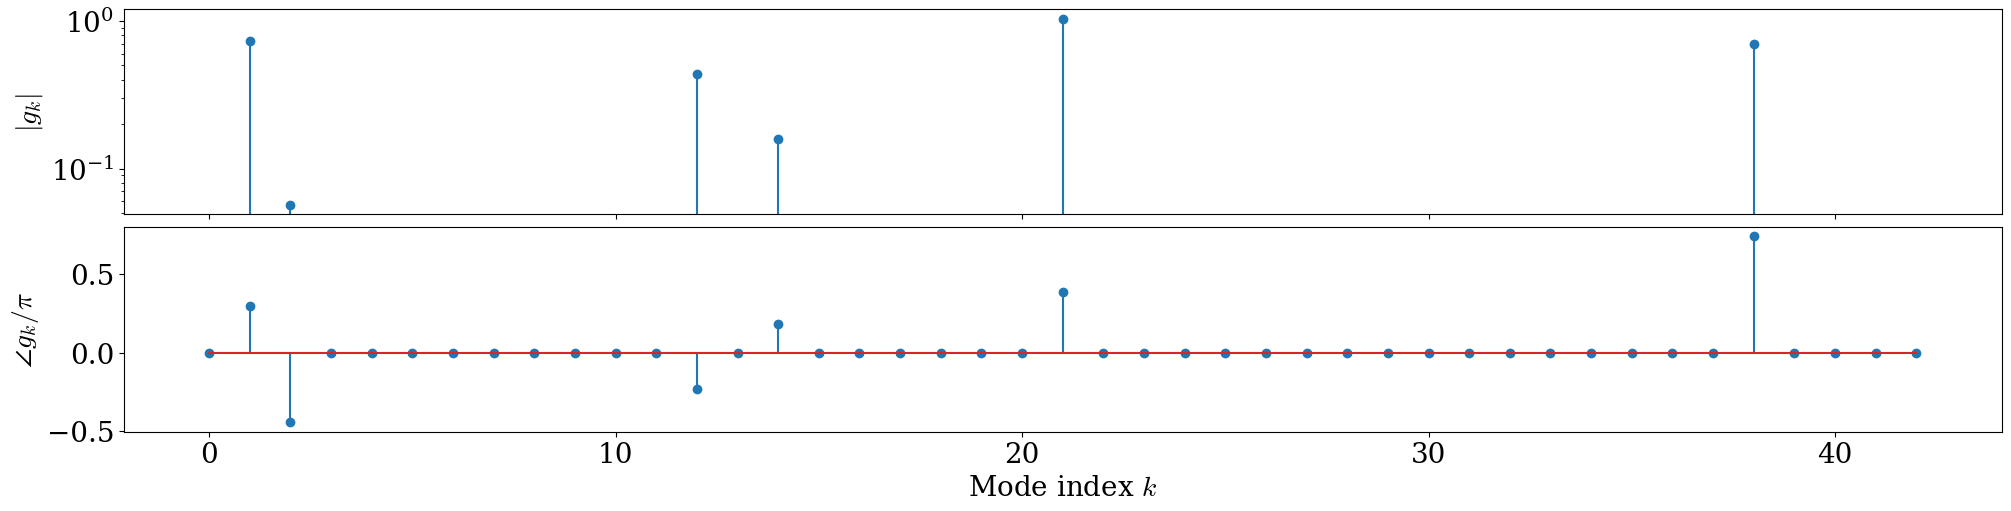

In [11]:
# =============================================================================
# Section 7 – Pump spectrum: amplitude and phase of the recovered pump vector
# =============================================================================
# Stem plots of the recovered pump vector g_p:
#   Top panel:    |g_p[k]| on a logarithmic scale — identifies dominant pump modes
#   Bottom panel: ∠g_p[k] / π — phase of each pump component

fig3, ax3 = plt.subplots(2, 1, figsize=(20, 5), sharex=True)

ax3[0].stem(np.abs(gp_back), label='$g_p$')
ax3[0].set_ylabel('$|g_k|$')
ax3[0].set_yscale('log')  # Log scale to highlight the spread across orders of magnitude

ax3[1].stem(np.angle(gp_back) / np.pi, label='$g_p$')
ax3[1].set_ylabel(r'$\angle g_k / \pi$')
ax3[1].set_xlabel('Mode index $k$')

plt.show()

In [12]:
# Verify the shape of the sliced experimental scattering matrix array:
# Expected: (Nfc, Nparam, Nmodes, Nmodes)
np.shape(Sexp_tot)

(20, 1, 31, 31)

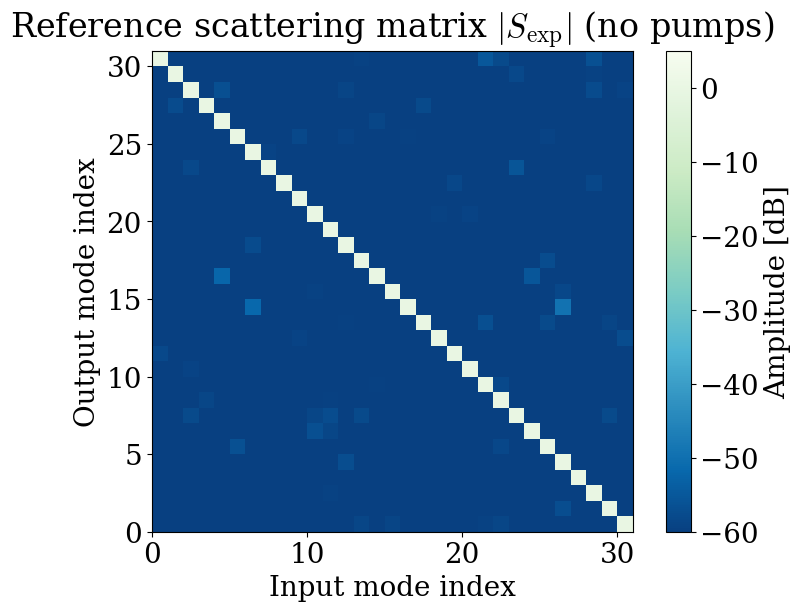

In [13]:
# =============================================================================
# Section 8 – Static plot: no-pump reference scattering matrix
# =============================================================================
# Select the scattering matrix measured with zero frequency-comb and zero
# parametric pump amplitudes (indices [0, 0]), i.e., the baseline (reference) response.

Sexp_plot     = Sexp_tot[0, 0, :, :]
Sexp_plot_abs = np.abs(Sexp_plot)
Sexp_plot_abs_dB = my.dB(Sexp_plot_abs / S0exp_ref)  # Normalize to reference diagonal

plt.figure(figsize=(8, 6))
plt.imshow(Sexp_plot_abs_dB, cmap='GnBu_r',
           extent=[0, Nmodes, 0, Nmodes], vmin=-60, vmax=5)
plt.colorbar(label='Amplitude [dB]')
plt.xlabel('Input mode index')
plt.ylabel('Output mode index')
plt.title('Reference scattering matrix $|S_\\mathrm{exp}|$ (no pumps)')
plt.show()

In [14]:
# =============================================================================
# Section 9 – Save data to disk
# =============================================================================
# Set the output file path for saving the processed data.
# NOTE: update this path to your preferred output directory before running.
#file_path = '/home/michele/Desktop/Sexp_abs_dB_3.npy'

In [15]:
# Save the processed data to a .npz file.
# Uncomment the lines below to enable saving.
#
# Saved arrays:
#   - Sexp_abs_dB : experimental scattering matrix magnitude in dB [Nmodes × Nmodes]
#   - gp_back     : recovered pump vector from the inverse problem (complex, all modes)
#   - omega_back  : resonance frequencies used during the optimization [rad/GHz]

# np.savez(file_path,
#          Sexp_abs_dB=Sexp_plot_abs_dB,
#          gp_back=gp_back,
#          omega_back=omega_back)
# print(f"Data saved to {file_path}")